In [ ]:
!pip -q install lpips scikit-image diffusers transformers accelerate safetensors huggingface_hub

In [1]:
import os
import gc
import math
import time
import json
import random
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm.auto import tqdm

from diffusers import StableDiffusionInpaintPipeline, DDPMScheduler
from huggingface_hub import login

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

import lpips

print("All imports loaded successfully.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


All imports loaded successfully.


In [2]:
print("Torch:", torch.__version__)
print("LPIPS imported successfully")

Torch: 2.10.0+cu128
LPIPS imported successfully


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Device: cuda


In [4]:

BASE_DIR = Path("/kaggle/working/studentA02_celeba_inpainting")
CKPT_DIR = BASE_DIR / "checkpoints"
RESULT_DIR = BASE_DIR / "results"
SAMPLE_DIR = BASE_DIR / "samples"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("RESULT_DIR:", RESULT_DIR)
print("SAMPLE_DIR:", SAMPLE_DIR)

BASE_DIR: /kaggle/working/studentA02_celeba_inpainting
CKPT_DIR: /kaggle/working/studentA02_celeba_inpainting/checkpoints
RESULT_DIR: /kaggle/working/studentA02_celeba_inpainting/results
SAMPLE_DIR: /kaggle/working/studentA02_celeba_inpainting/samples


In [ ]:


train_csv_path = "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/train_3000.csv"
val_csv_path = "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/val_500.csv"
test_csv_path = "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/test_500.csv"

image_root = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

print("train_csv_path:", train_csv_path)
print("val_csv_path:", val_csv_path)
print("test_csv_path:", test_csv_path)
print("image_root:", image_root)

train_csv_path: /kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/train_3000.csv
val_csv_path: /kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/val_500.csv
test_csv_path: /kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/test_500.csv
image_root: /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba


In [6]:
print(pd.read_csv(train_csv_path).head())
print(pd.read_csv(val_csv_path).head())
print(pd.read_csv(test_csv_path).head())

print("Train rows:", len(pd.read_csv(train_csv_path)))
print("Val rows:", len(pd.read_csv(val_csv_path)))
print("Test rows:", len(pd.read_csv(test_csv_path)))

   split    filename
0  train  111044.jpg
1  train  067554.jpg
2  train  159224.jpg
3  train  002029.jpg
4  train  126480.jpg
   split    filename
0   test  127326.jpg
1    val  057550.jpg
2  train  180659.jpg
3    val  137711.jpg
4  train  081055.jpg
   split    filename
0  train  154335.jpg
1  train  069908.jpg
2  train  199500.jpg
3  train  158124.jpg
4  train  023646.jpg
Train rows: 3000
Val rows: 500
Test rows: 500


“We set teacher loss weight to 0.1 so the teacher provides guidance without overpowering the student’s own diffusion objective

In [ ]:
CFG = {
    "image_size": 256,
    "batch_size": 1,        #We use batch size 1 because teacher-guided latent diffusion training is memory expensive.
    "num_workers": 0,
    "epochs": 20,
    "lr": 1e-4,
    "num_train_timesteps": 1000,
    "num_sample_steps": 100,
    "teacher_loss_weight": 0.1, #The teacher-guided loss is multiplied by 0.1 when combined with the student’s main loss
    "train_csv": train_csv_path,
    "val_csv": val_csv_path,
    "test_csv": test_csv_path,
    "image_root": image_root,
    "student": {
        "in_channels": 9,
        "out_channels": 4,
        "base_channels": 64,
        "weight_mask": 4.0
    },
    "masking": {
        "rectangle_prob": 0.25,
        "brush_prob": 0.25,
        "center_prob": 0.25,
        "blob_prob": 0.25
    }
}

print(json.dumps(CFG, indent=2))

{
  "image_size": 256,
  "batch_size": 1,
  "num_workers": 0,
  "epochs": 20,
  "lr": 0.0001,
  "num_train_timesteps": 1000,
  "num_sample_steps": 100,
  "teacher_loss_weight": 0.1,
  "train_csv": "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/train_3000.csv",
  "val_csv": "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/val_500.csv",
  "test_csv": "/kaggle/input/datasets/alice02026/celeba-fixed-dataset/celeba_fixed_dataset/test_500.csv",
  "image_root": "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba",
  "student": {
    "in_channels": 9,
    "out_channels": 4,
    "base_channels": 64,
    "weight_mask": 4.0
  },
  "masking": {
    "rectangle_prob": 0.25,
    "brush_prob": 0.25,
    "center_prob": 0.25,
    "blob_prob": 0.25
  }
}


In [8]:
HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN:
    login(token=HF_TOKEN)

teacher_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-inpainting",
    torch_dtype=torch.float16
).to(device)

teacher_pipe.set_progress_bar_config(disable=True)

teacher_unet = teacher_pipe.unet.eval()
teacher_vae = teacher_pipe.vae.eval()
teacher_text_encoder = teacher_pipe.text_encoder.eval()
teacher_tokenizer = teacher_pipe.tokenizer

scheduler = DDPMScheduler.from_config(teacher_pipe.scheduler.config)
vae = teacher_vae

for p in teacher_unet.parameters():
    p.requires_grad = False
for p in vae.parameters():
    p.requires_grad = False
for p in teacher_text_encoder.parameters():
    p.requires_grad = False

print("Teacher loaded.")

model_index.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-inpainting/snapshots/5f74973cbb64c8568780732c17f43eb269d63a0d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Teacher loaded.


In [9]:
def get_null_text_embeddings(batch_size):
    text_inputs = teacher_tokenizer(
        [""] * batch_size,
        padding="max_length",
        max_length=teacher_tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt"
    )
    input_ids = text_inputs.input_ids.to(device)
    with torch.no_grad():
        prompt_embeds = teacher_text_encoder(input_ids)[0]
    return prompt_embeds

In [ ]:
to_tensor_01 = transforms.ToTensor()

def pil_to_tensor_neg1_1(image_pil):
    x = to_tensor_01(image_pil)
    return x * 2.0 - 1.0

def tensor_neg1_1_to_01(x):
    return ((x.clamp(-1, 1) + 1.0) / 2.0).clamp(0, 1)

def tensor_01_to_pil(x):
    x = x.detach().cpu().clamp(0, 1)
    x = (x * 255.0).byte().permute(1, 2, 0).numpy()
    return Image.fromarray(x)

def pil_mask_to_tensor(mask_pil):
    mask_np = np.array(mask_pil.convert("L"), dtype=np.float32) / 255.0
    mask_np = (mask_np > 0.5).astype(np.float32)
    return torch.from_numpy(mask_np).unsqueeze(0)  # [1, H, W] required for mask conditioning
#We convert the mask into a binary single-channel tensor so it can be used as explicit conditioning input to the student model

We convert PIL images into [-1,1] tensors because the VAE encoder expects that normalized range.

This cell defines helper functions for converting images between PIL and tensor form, normalizing image values between [0,1] and [-1,1], and converting binary masks into tensor format for latent inpainting

In [11]:
def make_rectangle_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    rect_w = random.randint(w // 6, w // 2)
    rect_h = random.randint(h // 6, h // 2)
    x1 = random.randint(0, w - rect_w)
    y1 = random.randint(0, h - rect_h)
    x2 = x1 + rect_w
    y2 = y1 + rect_h

    draw.rectangle([x1, y1, x2, y2], fill=255)
    area = ((x2 - x1) * (y2 - y1)) / (w * h)
    return mask, area

def make_random_center_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    rect_w = random.randint(w // 5, w // 2)
    rect_h = random.randint(h // 5, h // 2)

    cx = w // 2 + random.randint(-w // 10, w // 10)
    cy = h // 2 + random.randint(-h // 10, h // 10)

    x1 = max(0, cx - rect_w // 2)
    y1 = max(0, cy - rect_h // 2)
    x2 = min(w, x1 + rect_w)
    y2 = min(h, y1 + rect_h)

    draw.rectangle([x1, y1, x2, y2], fill=255)
    area = ((x2 - x1) * (y2 - y1)) / (w * h)
    return mask, area

def make_blob_mask_pil(size):
    w, h = size
    mask_np = np.zeros((h, w), dtype=np.uint8)

    num_blobs = random.randint(3, 6)
    for _ in range(num_blobs):
        radius = random.randint(min(w, h) // 12, min(w, h) // 5)
        cx = random.randint(radius, w - radius)
        cy = random.randint(radius, h - radius)

        yy, xx = np.ogrid[:h, :w]
        circle = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
        mask_np[circle] = 255

    area = (mask_np > 0).mean()
    return Image.fromarray(mask_np).convert("L"), float(area)

def make_brush_mask_pil(size):
    w, h = size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    num_strokes = random.randint(2, 5)
    for _ in range(num_strokes):
        num_points = random.randint(4, 8)
        points = []
        for _ in range(num_points):
            points.append((random.randint(0, w - 1), random.randint(0, h - 1)))
        width = random.randint(max(8, w // 30), max(16, w // 12))
        draw.line(points, fill=255, width=width)
        for x, y in points:
            r = width // 2
            draw.ellipse((x - r, y - r, x + r, y + r), fill=255)

    mask_np = np.array(mask)
    area = (mask_np > 0).mean()
    return mask, float(area)

def sample_hybrid_mask_pil(size, masking_cfg):
    types = ["rectangle", "brush", "center", "blob"]
    probs = [
        masking_cfg["rectangle_prob"],
        masking_cfg["brush_prob"],
        masking_cfg["center_prob"],
        masking_cfg["blob_prob"]
    ]

    mask_type = random.choices(types, weights=probs, k=1)[0]

    if mask_type == "rectangle":
        mask, area = make_rectangle_mask_pil(size)
    elif mask_type == "brush":
        mask, area = make_brush_mask_pil(size)
    elif mask_type == "center":
        mask, area = make_random_center_mask_pil(size)
    else:
        mask, area = make_blob_mask_pil(size)

    return mask, mask_type, area

In [12]:
def apply_mask_to_image(image_pil, mask_pil):
    image_np = np.array(image_pil).astype(np.uint8)
    mask_np = np.array(mask_pil.convert("L")) > 127

    masked_np = image_np.copy()
    masked_np[mask_np] = 0

    return Image.fromarray(masked_np)

In [13]:
class FixedSubsetImageDataset(Dataset):
    def __init__(self, csv_path, image_root, image_size=256):
        self.df = pd.read_csv(csv_path)
        self.image_root = Path(image_root)
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df.iloc[idx]["filename"]
        img_path = self.image_root / fname

        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.image_size, self.image_size), Image.BICUBIC)

        return {
            "filename": fname,
            "image_pil": img
        }

In [14]:
train_ds = FixedSubsetImageDataset(CFG["train_csv"], CFG["image_root"], CFG["image_size"])
val_ds = FixedSubsetImageDataset(CFG["val_csv"], CFG["image_root"], CFG["image_size"])
test_ds = FixedSubsetImageDataset(CFG["test_csv"], CFG["image_root"], CFG["image_size"])

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

Train: 3000
Val: 500
Test: 500


In [15]:
def collate_identity(batch):
    return batch

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    collate_fn=collate_identity,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    collate_fn=collate_identity,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_identity,
    pin_memory=True
)

print("Train batches:", len(train_loader))

Train batches: 3000


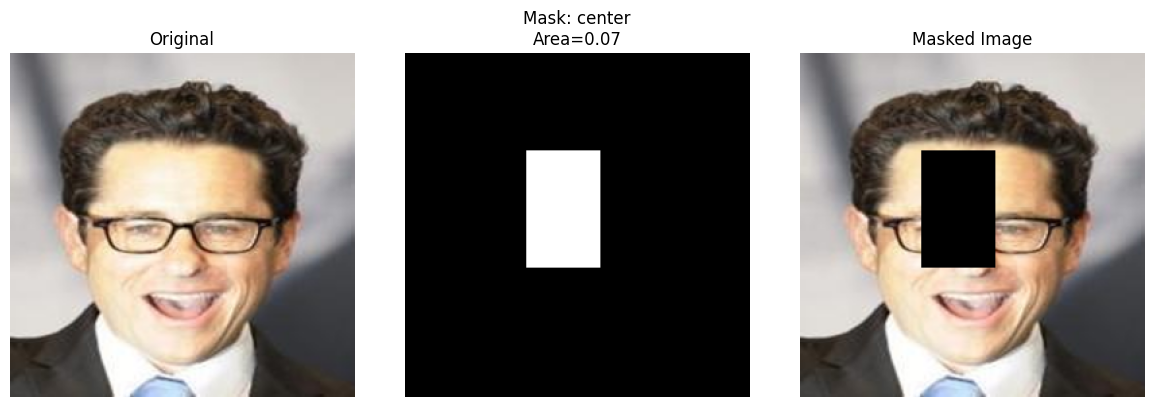

In [17]:
sample_img = train_ds[0]["image_pil"]

mask, mask_type, area = sample_hybrid_mask_pil(sample_img.size, CFG["masking"])
masked_img = apply_mask_to_image(sample_img, mask)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title(f"Mask: {mask_type}\nArea={area:.2f}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(masked_img)
plt.title("Masked Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#encoding RGB images into latent space using the frozen VAE
def encode_image_to_latent(vae, image_tensor):
    vae_dtype = next(vae.parameters()).dtype
    image_tensor = image_tensor.to(device=device, dtype=vae_dtype)
    with torch.no_grad():  #We use no-grad mode because the VAE is frozen and used only for latent conversion.
        latent = vae.encode(image_tensor).latent_dist.sample() #We encode the image into the VAE latent distribution and sample the latent representation.
        latent = latent * 0.18215
    return latent

def encode_to_latent_from_pil_list(pil_list): #We convert the list of PIL images into a batch tensor in the [-1,1] range, which is required by the VAE.
    images_t = torch.stack([pil_to_tensor_neg1_1(img) for img in pil_list], dim=0).to(device)
    latents = encode_image_to_latent(vae, images_t)#Calls the first function to convert the image batch into latent batch.
    return images_t.float(), latents.float()

In [ ]:
#Convert raw image samples into a complete latent inpainting training package
def prepare_train_batch(samples):
    orig_pils = [s["image_pil"] for s in samples]
    filenames = [s["filename"] for s in samples]

    mask_pils = []
    mask_types = []
    mask_areas = []
    masked_pils = []

    #Generate hybrid mask and masked image for each sample
    for img in orig_pils:
        mask, mask_type, area = sample_hybrid_mask_pil(img.size, CFG["masking"])
        masked = apply_mask_to_image(img, mask)

        mask_pils.append(mask)
        mask_types.append(mask_type)
        mask_areas.append(area)
        masked_pils.append(masked)
    #Encode original &masked images into latents
    orig_t, latents = encode_to_latent_from_pil_list(orig_pils)
    _, masked_latents = encode_to_latent_from_pil_list(masked_pils)
    #masks into binary tensors
    mask_t = torch.stack([pil_mask_to_tensor(m) for m in mask_pils], dim=0).to(device).float()

    return {
        "filenames": filenames,
        "orig_pils": orig_pils,
        "mask_pils": mask_pils,
        "masked_pils": masked_pils,
        "mask_types": mask_types,
        "mask_areas": mask_areas,
        "orig_t": orig_t.float(),
        "mask_t": mask_t.float(),
        "latents": latents.float(),
        "masked_latents": masked_latents.float()
    }

In [20]:
def teacher_predict(teacher_unet, latents, t, mask, masked_latent):
    with torch.no_grad():
        mask_latent = F.interpolate(mask, size=latents.shape[-2:], mode="nearest")
        inp = torch.cat([latents, mask_latent, masked_latent], dim=1)
        prompt_embeds = get_null_text_embeddings(latents.size(0))
        noise_pred = teacher_unet(inp, t, encoder_hidden_states=prompt_embeds).sample
    return noise_pred

we create the same kind of latent inpainting input
give it to the SD2 UNet
the teacher predicts what the noise should be
that teacher prediction becomes a guidance target for the student

In [21]:
def prepare_input(latents_noisy, mask, masked_latent):
    mask_latent = F.interpolate(
        mask,
        size=latents_noisy.shape[-2:],
        mode="nearest"
    )
    return torch.cat([latents_noisy, mask_latent, masked_latent], dim=1)

The student needs three things:

noisy latent → what needs denoising
mask → where the missing region is
masked latent → visible context around the missing area

This function combines them into one tensor.

first encode the diffusion timestep using sinusoidal embedding, then use residual blocks for feature extraction with timestep conditioning, down blocks for encoder-side compression, and up blocks for decoder-side reconstruction with skip connections.

In [ ]:
def sinusoidal_embedding(timesteps, dim):   #tells the model which diffusion step it is in
    half = dim // 2
    emb = math.log(10000) / (half - 1)
    emb = torch.exp(torch.arange(half, device=timesteps.device) * -emb)
    emb = timesteps.float()[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

class ResBlock(nn.Module):                       #extracts features and injects timestep information
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)#We project the timestep embedding into the channel dimension so it can be added directly to the feature map
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time_proj(t_emb)[:, :, None, None] #injects timestep information into every spatial location of the feature map.
        h = self.norm1(h)
        h = self.act(h)
        #Refine the features with a second convolution, normalization, and activation
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.skip(x)

class DownBlock(nn.Module):                      #extracts features and downsamples
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.res = ResBlock(in_ch, out_ch, time_dim)
        self.down = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

    def forward(self, x, t_emb):
        x = self.res(x, t_emb)
        skip = x
        x = self.down(x)
        return x, skip

class UpBlock(nn.Module):                           #upsamples and merges skip features
    def __init__(self, in_ch, skip_ch, out_ch, time_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1)
        self.res = ResBlock(out_ch + skip_ch, out_ch, time_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res(x, t_emb)
        return x  #Return the updated feature.

timestep embedding tells the model the diffusion step
ResBlock injects time embedding into feature maps
GroupNorm is used because batch size is 1
DownBlock saves skip features
UpBlock merges skip features to recover detail

In [ ]:
class StudentUNet(nn.Module):        #The model input has 9 channel(noisy latent+binary mask+masked-image latent.
    def __init__(self, in_channels=9, out_channels=4, base_channels=64, time_dim=256):  #The Stable Diffusion VAE latent space has 4 channels,4-channel latent noise
        super().__init__()
        self.time_dim = time_dim            #Saves timestep embedding dimension inside the model

        self.time_mlp = nn.Sequential(    #raw sinusoidal embedding,refine them with a small MLP
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.conv_in = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        
        #encoder #Down block 1:64 channels → 128 channels
        self.down1 = DownBlock(base_channels, base_channels * 2, time_dim)
        #Down block 2:128 channels → 256 channels
        self.down2 = DownBlock(base_channels * 2, base_channels * 4, time_dim)

        #Middle:to process the deepest latent features before reconstruction.
        self.mid1 = ResBlock(base_channels * 4, base_channels * 4, time_dim)
        self.mid2 = ResBlock(base_channels * 4, base_channels * 4, time_dim)

        #First decoder stage:256 to 128 to 64
        self.up2 = UpBlock(base_channels * 4, base_channels * 4, base_channels * 2, time_dim)
        self.up1 = UpBlock(base_channels * 2, base_channels * 2, base_channels, time_dim)

        self.out_norm = nn.GroupNorm(8, base_channels)
        self.out_act = nn.SiLU()
        self.conv_out = nn.Conv2d(base_channels, out_channels, 3, padding=1)

    def forward(self, x, timesteps):    #Forward pass
        t_emb = sinusoidal_embedding(timesteps, self.time_dim)
        t_emb = self.time_mlp(t_emb)

        x0 = self.conv_in(x)

        x1, skip1 = self.down1(x0, t_emb)    #skip1 and skip2 are saved for decoder use later
        x2, skip2 = self.down2(x1, t_emb)

        x = self.mid1(x2, t_emb)
        x = self.mid2(x, t_emb)

        x = self.up2(x, skip2, t_emb)
        x = self.up1(x, skip1, t_emb)

        x = self.out_norm(x)
        x = self.out_act(x)
        x = self.conv_out(x)
        return x   #Predicted 4-channel latent noise prediction &This predicted noise is used in both the diffusion objective and teacher distillation

In [24]:
model = StudentUNet(
    in_channels=CFG["student"]["in_channels"],
    out_channels=CFG["student"]["out_channels"],
    base_channels=CFG["student"]["base_channels"]
).to(device).float()

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])

n_params = sum(p.numel() for p in model.parameters())
print("Student parameters:", n_params)

Student parameters: 6697540


This loss function measures how close the student’s predicted noise is to the target noise, while giving higher weight to the masked region

In [ ]:
def masked_weighted_noise_loss(pred_noise, target_noise, mask_t, weight_mask=4.0):
    mask_latent = F.interpolate(mask_t, size=pred_noise.shape[-2:], mode="nearest") #Resizes the mask to match the spatial size of pred_noise
    weight = 1.0 + (weight_mask - 1.0) * mask_latent #Builds a weight map pixel by pixe
    loss_map = (pred_noise - target_noise) ** 2 #pixel-wise squared error
    loss = (loss_map * weight).mean()
    return loss

In [ ]:
#prepare the batch for training & val
def run_one_step(sample_batch, train_mode=True):
    batch = prepare_train_batch(sample_batch)

    #Extract important tensors
    mask = batch["mask_t"].to(device).float()
    latents = batch["latents"].to(device).float()
    masked_latent = batch["masked_latents"].to(device).float()

    noise = torch.randn_like(latents).float()
    timesteps = torch.randint(
        0,
        CFG["num_train_timesteps"],
        (latents.size(0),),
        device=device
    ).long()
    #Add noise to clean latent
    latents_noisy = scheduler.add_noise(latents, noise, timesteps).float()
    model_input = prepare_input(latents_noisy, mask, masked_latent).float()

    if train_mode:
        model.train()
        optimizer.zero_grad()#clearing old gradients

        noise_pred_student = model(model_input, timesteps)

#Runs the frozen SD2 teacher on the same noisy latent setup
        noise_pred_teacher = teacher_predict(
            teacher_unet,
            latents_noisy.half(),
            timesteps,
            mask.half(),
            masked_latent.half()
        ).float()
#Main diffusion loss  between student pred vs gaussian noise,learns to predict the true noise
        loss_diff = masked_weighted_noise_loss(
            noise_pred_student,
            noise,
            mask,
            weight_mask=CFG["student"]["weight_mask"]
        )
#Teacher distillation loss between student pred vs teacher pred,learns to mimic the teacher's noise prediction which contains richer semantic guidance
        loss_teacher = masked_weighted_noise_loss(
            noise_pred_student,
            noise_pred_teacher,
            mask,
            weight_mask=CFG["student"]["weight_mask"]
        )
#Combine losses
        loss = loss_diff + CFG["teacher_loss_weight"] * loss_teacher
        loss.backward() #Computes gradients with respect to the student parameters
        optimizer.step()#Updates the student model parameter

    else:
        model.eval()         #we compute the same losses but do not update the model
        with torch.no_grad():
            noise_pred_student = model(model_input, timesteps)

            noise_pred_teacher = teacher_predict(
                teacher_unet,
                latents_noisy.half(),
                timesteps,
                mask.half(),
                masked_latent.half()
            ).float()

            loss_diff = masked_weighted_noise_loss(
                noise_pred_student,
                noise,
                mask,
                weight_mask=CFG["student"]["weight_mask"]
            )

            loss_teacher = masked_weighted_noise_loss(
                noise_pred_student,
                noise_pred_teacher,
                mask,
                weight_mask=CFG["student"]["weight_mask"]
            )

            loss = loss_diff + CFG["teacher_loss_weight"] * loss_teacher

    return {
        "loss_total": float(loss.item()),
        "loss_diff": float(loss_diff.item()),
        "loss_teacher": float(loss_teacher.item())
    }

A01 learned from:

true noise only

A02 learns from:

true noise + teacher prediction



In [27]:
batch = next(iter(train_loader))
print(type(batch), len(batch))
print(batch[0].keys())

test_out = run_one_step(batch, train_mode=True)
print(test_out)

<class 'list'> 1
dict_keys(['filename', 'image_pil'])
{'loss_total': 1.7264862060546875, 'loss_diff': 1.568750262260437, 'loss_teacher': 1.5773590803146362}


In [28]:
import shutil

In [31]:
#combine checkpoints in zip bundle
import zipfile
import json
from pathlib import Path

def save_a02_bundle(
    result_dir,
    cfg,
    best_ckpt_path,
    latest_ckpt_path,
    history_path,
    zip_name="studentA02_deployment_bundle.zip"
):
    result_dir = Path(result_dir)
    result_dir.mkdir(parents=True, exist_ok=True)

    config_path = result_dir / "studentA02_config.json"
    metadata_path = result_dir / "studentA02_bundle_info.txt"
    deploy_zip_path = result_dir / zip_name

    with open(config_path, "w") as f:
        json.dump(cfg, f, indent=2)

    with open(metadata_path, "w") as f:
        f.write("Student A02 Deployment Bundle\n")
        f.write("Project: Lightweight Diffusion Inpainting\n\n")
        f.write(f"Best checkpoint: {best_ckpt_path.name}\n")
        f.write(f"Latest checkpoint: {latest_ckpt_path.name}\n")
        f.write(f"Epochs: {cfg['epochs']}\n")
        f.write(f"Image size: {cfg['image_size']}\n")
        f.write(f"Base channels: {cfg['student']['base_channels']}\n")
        f.write(f"Teacher loss weight: {cfg['teacher_loss_weight']}\n")
        f.write(f"Sampling steps: {cfg['num_sample_steps']}\n")

    files_to_package = []
    for p in [best_ckpt_path, latest_ckpt_path, history_path, config_path, metadata_path]:
        p = Path(p)
        if p.exists():
            files_to_package.append(p)

    with zipfile.ZipFile(deploy_zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for file_path in files_to_package:
            zipf.write(file_path, arcname=file_path.name)

    return deploy_zip_path

#Training

history = []

best_ckpt_path = CKPT_DIR / "studentA02_best.pt"
latest_ckpt_path = CKPT_DIR / "studentA02_latest.pt"
history_path = RESULT_DIR / "studentA02_train_history.csv"

best_val = float("inf")

print("Training will save to:")
print(" best   :", best_ckpt_path)
print(" latest :", latest_ckpt_path)
print(" history:", history_path)

for epoch in range(1, CFG["epochs"] + 1):
    print(f"\nStarting epoch {epoch} ...")

    train_total_losses = []
    train_diff_losses = []
    train_teacher_losses = []

    val_total_losses = []
    val_diff_losses = []
    val_teacher_losses = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch} Train"):
        loss_dict = run_one_step(batch, train_mode=True)
        train_total_losses.append(loss_dict["loss_total"])
        train_diff_losses.append(loss_dict["loss_diff"])
        train_teacher_losses.append(loss_dict["loss_teacher"])

    for batch in tqdm(val_loader, desc=f"Epoch {epoch} Val"):
        loss_dict = run_one_step(batch, train_mode=False)
        val_total_losses.append(loss_dict["loss_total"])
        val_diff_losses.append(loss_dict["loss_diff"])
        val_teacher_losses.append(loss_dict["loss_teacher"])

    train_total = float(np.mean(train_total_losses))
    train_diff = float(np.mean(train_diff_losses))
    train_teacher = float(np.mean(train_teacher_losses))

    val_total = float(np.mean(val_total_losses))
    val_diff = float(np.mean(val_diff_losses))
    val_teacher = float(np.mean(val_teacher_losses))

    history.append({
        "epoch": epoch,
        "train_total": train_total,
        "train_diff": train_diff,
        "train_teacher": train_teacher,
        "val_total": val_total,
        "val_diff": val_diff,
        "val_teacher": val_teacher
    })

    print(
        f"Epoch {epoch}: "
        f"train_total={train_total:.4f}, train_diff={train_diff:.4f}, train_teacher={train_teacher:.4f} | "
        f"val_total={val_total:.4f}, val_diff={val_diff:.4f}, val_teacher={val_teacher:.4f}"
    )

    latest_payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val": best_val,
        "history": history,
        "cfg": CFG
    }

    torch.save(latest_payload, latest_ckpt_path)

    print(
        "Saved latest checkpoint:",
        latest_ckpt_path,
        "| exists:",
        latest_ckpt_path.exists(),
        "| size:",
        latest_ckpt_path.stat().st_size if latest_ckpt_path.exists() else -1,
        "bytes"
    )

    if val_total < best_val:
        best_val = val_total

        best_payload = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val": best_val,
            "history": history,
            "cfg": CFG
        }

        torch.save(best_payload, best_ckpt_path)

        print(
            "Saved new best checkpoint:",
            best_ckpt_path,
            "| exists:",
            best_ckpt_path.exists(),
            "| size:",
            best_ckpt_path.stat().st_size if best_ckpt_path.exists() else -1,
            "bytes"
        )

    pd.DataFrame(history).to_csv(history_path, index=False)

    print(
        "Saved training history:",
        history_path,
        "| exists:",
        history_path.exists(),
        "| size:",
        history_path.stat().st_size if history_path.exists() else -1,
        "bytes"
    )

    deploy_zip_path = save_a02_bundle(
        result_dir=RESULT_DIR,
        cfg=CFG,
        best_ckpt_path=best_ckpt_path,
        latest_ckpt_path=latest_ckpt_path,
        history_path=history_path,
        zip_name="studentA02_deployment_bundle.zip"
    )

    print(
        "Updated deployment bundle:",
        deploy_zip_path,
        "| exists:",
        deploy_zip_path.exists(),
        "| size:",
        round(deploy_zip_path.stat().st_size / (1024 * 1024), 2) if deploy_zip_path.exists() else -1,
        "MB"
    )

print("\nTraining finished.")

if best_ckpt_path.exists():
    test_ckpt = torch.load(best_ckpt_path, map_location=device)
    print("Best checkpoint load test passed. Epoch:", test_ckpt["epoch"])

if latest_ckpt_path.exists():
    test_ckpt_latest = torch.load(latest_ckpt_path, map_location=device)
    print("Latest checkpoint load test passed. Epoch:", test_ckpt_latest["epoch"])

final_bundle = RESULT_DIR / "studentA02_deployment_bundle.zip"
print("\nFinal bundle:", final_bundle)
print("Bundle exists:", final_bundle.exists())
print("Bundle size (MB):", round(final_bundle.stat().st_size / (1024 * 1024), 2) if final_bundle.exists() else -1)

Training will save to:
 best   : /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_best.pt
 latest : /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_latest.pt
 history: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_train_history.csv

Starting epoch 1 ...


Epoch 1 Train:   0%|          | 0/3000 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1: train_total=0.2633, train_diff=0.2492, train_teacher=0.1408 | val_total=0.2488, val_diff=0.2357, val_teacher=0.1308
Saved latest checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_latest.pt | exists: True | size: 80477371 bytes
Saved new best checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_best.pt | exists: True | size: 80476671 bytes
Saved training history: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_train_history.csv | exists: True | size: 195 bytes
Updated deployment bundle: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_deployment_bundle.zip | exists: True | size: 140.41 MB

Starting epoch 2 ...


Epoch 2 Train:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Epoch 19 Val:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 19: train_total=0.2057, train_diff=0.1935, train_teacher=0.1228 | val_total=0.2151, val_diff=0.2025, val_teacher=0.1266
Saved latest checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_latest.pt | exists: True | size: 80479099 bytes
Saved training history: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_train_history.csv | exists: True | size: 2365 bytes
Updated deployment bundle: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_deployment_bundle.zip | exists: True | size: 140.54 MB

Starting epoch 20 ...


Epoch 20 Train:   0%|          | 0/3000 [00:00<?, ?it/s]

Epoch 20 Val:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 20: train_total=0.2204, train_diff=0.2076, train_teacher=0.1281 | val_total=0.2070, val_diff=0.1949, val_teacher=0.1215
Saved latest checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_latest.pt | exists: True | size: 80479227 bytes
Saved training history: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_train_history.csv | exists: True | size: 2486 bytes
Updated deployment bundle: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_deployment_bundle.zip | exists: True | size: 140.55 MB

Training finished.
Best checkpoint load test passed. Epoch: 18
Latest checkpoint load test passed. Epoch: 20

Final bundle: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_deployment_bundle.zip
Bundle exists: True
Bundle size (MB): 140.55


In [32]:
print("Checkpoint files:")
for p in CKPT_DIR.glob("*"):
    print(" ", p.name, "|", p.stat().st_size, "bytes")

print("\nResult files:")
for p in RESULT_DIR.glob("*"):
    print(" ", p.name, "|", p.stat().st_size, "bytes")

bundle_path = RESULT_DIR / "studentA02_deployment_bundle.zip"
print("\nBundle exists:", bundle_path.exists())

if bundle_path.exists():
    import zipfile
    with zipfile.ZipFile(bundle_path, "r") as zipf:
        print("Files inside bundle:")
        print(zipf.namelist())

Checkpoint files:
  studentA02_best.pt | 80478335 bytes
  studentA02_latest.pt | 80479227 bytes

Result files:
  studentA02_train_history.csv | 2486 bytes
  studentA02_config.json | 838 bytes
  studentA02_bundle_info.txt | 239 bytes
  studentA02_deployment_bundle.zip | 147379406 bytes

Bundle exists: True
Files inside bundle:
['studentA02_best.pt', 'studentA02_latest.pt', 'studentA02_train_history.csv', 'studentA02_config.json', 'studentA02_bundle_info.txt']


   epoch  train_total  train_diff  train_teacher  val_total  val_diff  \
0      1     0.263326    0.249242       0.140836   0.248823  0.235743   
1      2     0.258130    0.244484       0.136459   0.262143  0.247160   
2      3     0.247673    0.234417       0.132556   0.225351  0.213382   
3      4     0.228866    0.216214       0.126520   0.240841  0.228064   
4      5     0.231896    0.219084       0.128121   0.221782  0.208715   

   val_teacher  
0     0.130796  
1     0.149826  
2     0.119686  
3     0.127772  
4     0.130669  


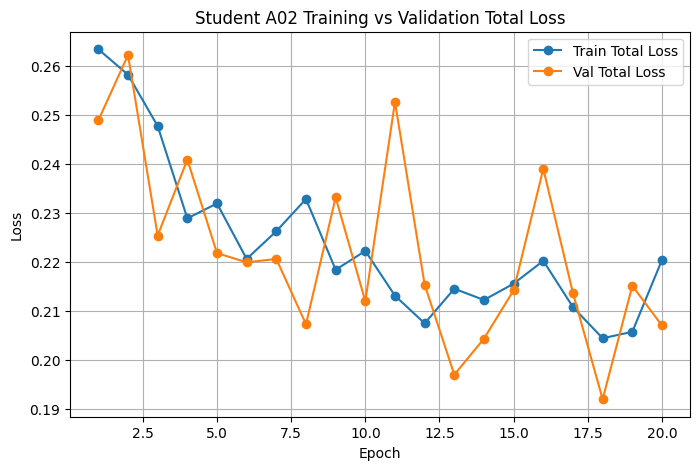

In [33]:
history_path = RESULT_DIR / "studentA02_train_history.csv"
history_df = pd.read_csv(history_path)

print(history_df.head())

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_total"], marker="o", label="Train Total Loss")
plt.plot(history_df["epoch"], history_df["val_total"], marker="o", label="Val Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Student A02 Training vs Validation Total Loss")
plt.legend()
plt.grid(True)
plt.show()

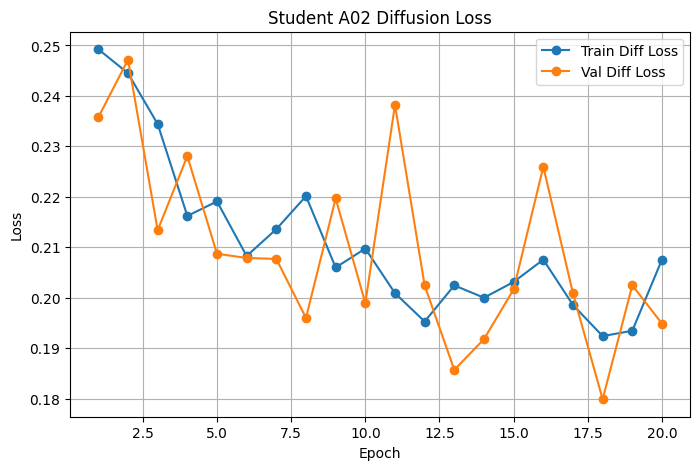

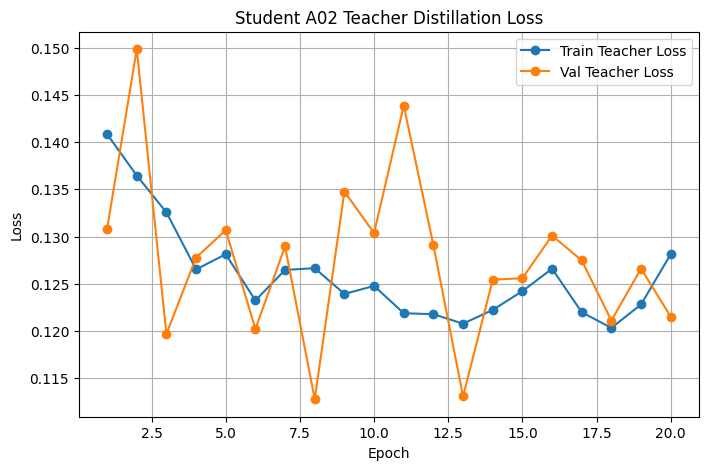

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_diff"], marker="o", label="Train Diff Loss")
plt.plot(history_df["epoch"], history_df["val_diff"], marker="o", label="Val Diff Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Student A02 Diffusion Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_teacher"], marker="o", label="Train Teacher Loss")
plt.plot(history_df["epoch"], history_df["val_teacher"], marker="o", label="Val Teacher Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Student A02 Teacher Distillation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
if best_ckpt_path.exists():
    ckpt_path = best_ckpt_path
elif latest_ckpt_path.exists():
    ckpt_path = latest_ckpt_path
else:
    raise FileNotFoundError("No checkpoint found.")

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Loaded checkpoint:", ckpt_path)
print("Loaded epoch:", ckpt["epoch"])

Loaded checkpoint: /kaggle/working/studentA02_celeba_inpainting/checkpoints/studentA02_best.pt
Loaded epoch: 18


In [36]:
@torch.no_grad()
def run_student_inpaint(model, image_pil, mask_pil, num_sample_steps):
    model.eval()

    image_t = pil_to_tensor_neg1_1(image_pil).unsqueeze(0).to(device).float()
    mask_t = pil_mask_to_tensor(mask_pil).unsqueeze(0).to(device).float()

    masked_pil = apply_mask_to_image(image_pil, mask_pil)
    masked_t = pil_to_tensor_neg1_1(masked_pil).unsqueeze(0).to(device).float()

    latents = encode_image_to_latent(vae, image_t).float()
    masked_latent = encode_image_to_latent(vae, masked_t).float()

    scheduler.set_timesteps(num_sample_steps, device=device)
    latents = torch.randn_like(latents).float()

    for t in scheduler.timesteps:
        t_batch = torch.full((latents.size(0),), int(t), device=device, dtype=torch.long)
        model_input = prepare_input(latents, mask_t, masked_latent).float()
        noise_pred = model(model_input, t_batch).float()
        latents = scheduler.step(noise_pred, t, latents).prev_sample.float()

    vae_dtype = next(vae.parameters()).dtype
    decoded = vae.decode((latents / 0.18215).to(dtype=vae_dtype)).sample
    decoded = decoded.float()

    pred_01 = tensor_neg1_1_to_01(decoded[0])
    pred_pil = tensor_01_to_pil(pred_01)
    return pred_pil

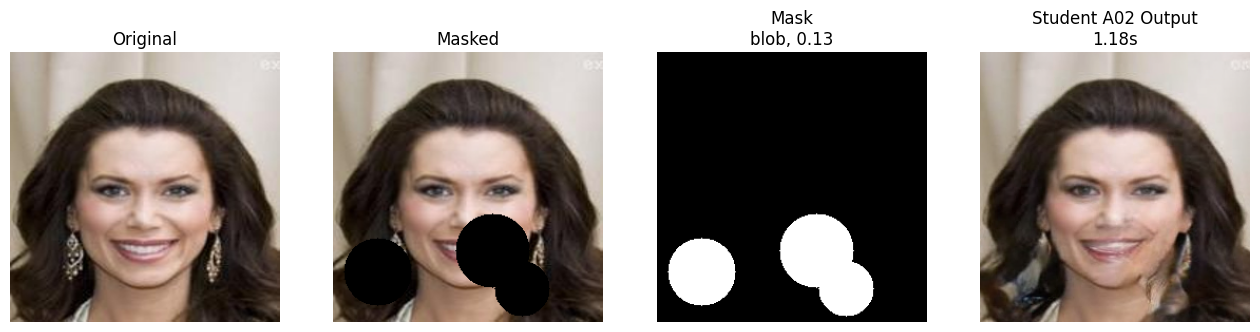

In [37]:
sample = test_ds[0]
orig = sample["image_pil"]
mask, mask_type, area = sample_hybrid_mask_pil(orig.size, CFG["masking"])
masked = apply_mask_to_image(orig, mask)

start = time.time()
pred = run_student_inpaint(model, orig, mask, CFG["num_sample_steps"])
elapsed = time.time() - start

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(masked)
plt.title("Masked")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(mask, cmap="gray")
plt.title(f"Mask\n{mask_type}, {area:.2f}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred)
plt.title(f"Student A02 Output\n{elapsed:.2f}s")
plt.axis("off")

plt.show()

In [38]:
lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()
print("LPIPS loaded.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth



  0%|          | 0.00/233M [00:00<?, ?B/s]
  3%|▎         | 8.12M/233M [00:00<00:02, 84.9MB/s]
 10%|█         | 23.5M/233M [00:00<00:01, 129MB/s] 
 17%|█▋        | 38.6M/233M [00:00<00:01, 142MB/s]
 24%|██▍       | 56.4M/233M [00:00<00:01, 160MB/s]
 31%|███       | 71.6M/233M [00:00<00:01, 158MB/s]
 38%|███▊      | 89.2M/233M [00:00<00:00, 167MB/s]
 46%|████▌     | 107M/233M [00:00<00:00, 172MB/s] 
 53%|█████▎    | 124M/233M [00:00<00:00, 175MB/s]
 60%|██████    | 141M/233M [00:00<00:00, 169MB/s]
 68%|██████▊   | 158M/233M [00:01<00:00, 173MB/s]
 75%|███████▍  | 175M/233M [00:01<00:00, 168MB/s]
 82%|████████▏ | 191M/233M [00:01<00:00, 163MB/s]
 89%|████████▊ | 207M/233M [00:01<00:00, 160MB/s]
100%|██████████| 233M/233M [00:01<00:00, 163MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS loaded.


In [39]:
def pil_to_np_float01(img):
    return np.array(img).astype(np.float32) / 255.0

def masked_region_metrics(gt_pil, pred_pil, mask_pil):
    gt = pil_to_np_float01(gt_pil)
    pred = pil_to_np_float01(pred_pil)
    mask = (np.array(mask_pil.convert("L")) > 127)

    gt_masked = gt.copy()
    pred_masked = pred.copy()

    gt_masked[~mask] = 0
    pred_masked[~mask] = 0

    psnr_val = psnr_metric(gt_masked, pred_masked, data_range=1.0)
    ssim_val = ssim_metric(gt_masked, pred_masked, channel_axis=2, data_range=1.0)

    gt_t = torch.from_numpy(gt_masked).permute(2, 0, 1).unsqueeze(0).to(device) * 2 - 1
    pred_t = torch.from_numpy(pred_masked).permute(2, 0, 1).unsqueeze(0).to(device) * 2 - 1

    with torch.no_grad():
        lpips_val = lpips_model(gt_t, pred_t).item()

    return psnr_val, ssim_val, lpips_val

In [40]:
GEN_DIR = RESULT_DIR / "generated_for_fid"
REAL_DIR = RESULT_DIR / "real_for_fid"

GEN_DIR.mkdir(parents=True, exist_ok=True)
REAL_DIR.mkdir(parents=True, exist_ok=True)

eval_rows = []

for i in tqdm(range(len(test_ds)), desc="Evaluating Student A02"):
    sample = test_ds[i]
    orig = sample["image_pil"]
    fname = sample["filename"]

    mask, mask_type, area = sample_hybrid_mask_pil(orig.size, CFG["masking"])

    start = time.time()
    pred = run_student_inpaint(model, orig, mask, CFG["num_sample_steps"])
    elapsed = time.time() - start

    psnr_val, ssim_val, lpips_val = masked_region_metrics(orig, pred, mask)

    pred.save(GEN_DIR / fname)
    orig.save(REAL_DIR / fname)

    eval_rows.append({
        "filename": fname,
        "mask_type": mask_type,
        "mask_area": area,
        "psnr_masked": psnr_val,
        "ssim_masked": ssim_val,
        "lpips_masked": lpips_val,
        "inference_time_sec": elapsed
    })

eval_df = pd.DataFrame(eval_rows)
eval_csv = RESULT_DIR / "studentA02_eval_metrics.csv"
eval_df.to_csv(eval_csv, index=False)

print("Saved evaluation CSV:", eval_csv)
print("Generated images:", GEN_DIR)
print("Real images:", REAL_DIR)

Evaluating Student A02:   0%|          | 0/500 [00:00<?, ?it/s]

Saved evaluation CSV: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_eval_metrics.csv
Generated images: /kaggle/working/studentA02_celeba_inpainting/results/generated_for_fid
Real images: /kaggle/working/studentA02_celeba_inpainting/results/real_for_fid


In [41]:
summary = {
    "project": "CSE499B - Lightweight Diffusion Models for Image Inpainting",
    "experiment": "Student A02 with SD2 teacher distillation",
    "image_size": CFG["image_size"],
    "epochs": CFG["epochs"],
    "batch_size": CFG["batch_size"],
    "lr": CFG["lr"],
    "teacher_loss_weight": CFG["teacher_loss_weight"],
    "weight_mask": CFG["student"]["weight_mask"],
    "num_sample_steps": CFG["num_sample_steps"],
    "parameter_count": int(sum(p.numel() for p in model.parameters()))
}

summary_path = RESULT_DIR / "studentA02_config_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)
print(json.dumps(summary, indent=2))

Saved: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_config_summary.json
{
  "project": "CSE499B - Lightweight Diffusion Models for Image Inpainting",
  "experiment": "Student A02 with SD2 teacher distillation",
  "image_size": 256,
  "epochs": 20,
  "batch_size": 1,
  "lr": 0.0001,
  "teacher_loss_weight": 0.1,
  "weight_mask": 4.0,
  "num_sample_steps": 100,
  "parameter_count": 6697540
}


In [42]:
summary_metrics = {
    "PSNR_masked_mean": float(eval_df["psnr_masked"].mean()),
    "SSIM_masked_mean": float(eval_df["ssim_masked"].mean()),
    "LPIPS_masked_mean": float(eval_df["lpips_masked"].mean()),
    "Inference_time_mean_sec": float(eval_df["inference_time_sec"].mean()),
    "Num_samples": int(len(eval_df))
}

print(json.dumps(summary_metrics, indent=2))

{
  "PSNR_masked_mean": 21.22296338381309,
  "SSIM_masked_mean": 0.8714379668235779,
  "LPIPS_masked_mean": 0.08842972988449037,
  "Inference_time_mean_sec": 0.6370953459739686,
  "Num_samples": 500
}


# FID block

In [43]:
!pip -q install torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.9 MB/s eta 0:00:00


In [44]:
GEN_DIR = RESULT_DIR / "generated_for_fid"
REAL_DIR = RESULT_DIR / "real_for_fid"

GEN_DIR.mkdir(parents=True, exist_ok=True)
REAL_DIR.mkdir(parents=True, exist_ok=True)

print("GEN_DIR:", GEN_DIR)
print("REAL_DIR:", REAL_DIR)
print("GEN exists:", GEN_DIR.exists())
print("REAL exists:", REAL_DIR.exists())

GEN_DIR: /kaggle/working/studentA02_celeba_inpainting/results/generated_for_fid
REAL_DIR: /kaggle/working/studentA02_celeba_inpainting/results/real_for_fid
GEN exists: True
REAL exists: True


In [45]:
gen_files = sorted(list(GEN_DIR.glob("*.jpg"))) + sorted(list(GEN_DIR.glob("*.png")))
real_files = sorted(list(REAL_DIR.glob("*.jpg"))) + sorted(list(REAL_DIR.glob("*.png")))

print("Generated files:", len(gen_files))
print("Real files:", len(real_files))

if len(gen_files) > 0:
    print("Example generated file:", gen_files[0])
if len(real_files) > 0:
    print("Example real file:", real_files[0])

Generated files: 500
Real files: 500
Example generated file: /kaggle/working/studentA02_celeba_inpainting/results/generated_for_fid/001192.jpg
Example real file: /kaggle/working/studentA02_celeba_inpainting/results/real_for_fid/001192.jpg


In [46]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import transforms as T

fid_metric = FrechetInceptionDistance(feature=2048).to(device)

to_tensor_255 = T.PILToTensor()

gen_files = sorted([p for p in GEN_DIR.glob("*.jpg")]) + sorted([p for p in GEN_DIR.glob("*.png")])
real_files = sorted([p for p in REAL_DIR.glob("*.jpg")]) + sorted([p for p in REAL_DIR.glob("*.png")])

print("Generated files:", len(gen_files))
print("Real files:", len(real_files))

for real_path, gen_path in tqdm(list(zip(real_files, gen_files)), desc="Computing FID"):
    real_img = Image.open(real_path).convert("RGB")
    gen_img = Image.open(gen_path).convert("RGB")

    real_t = to_tensor_255(real_img).unsqueeze(0).to(device)
    gen_t = to_tensor_255(gen_img).unsqueeze(0).to(device)

    fid_metric.update(real_t, real=True)
    fid_metric.update(gen_t, real=False)

fid_value = float(fid_metric.compute().item())
print("FID:", fid_value)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth

  0%|          | 0.00/91.2M [00:00<?, ?B/s]
 11%|█         | 10.1M/91.2M [00:00<00:00, 106MB/s]
 34%|███▍      | 31.2M/91.2M [00:00<00:00, 173MB/s]
 59%|█████▊    | 53.5M/91.2M [00:00<00:00, 200MB/s]
100%|██████████| 91.2M/91.2M [00:00<00:00, 215MB/s]


Generated files: 500
Real files: 500


Computing FID:   0%|          | 0/500 [00:00<?, ?it/s]

FID: 46.94912338256836


In [48]:
final_summary = {
    "experiment": "Student A02 with SD2 teacher distillation",
    "FID": fid_value,
    "PSNR_masked": float(eval_df["psnr_masked"].mean()),
    "SSIM_masked": float(eval_df["ssim_masked"].mean()),
    "LPIPS_masked": float(eval_df["lpips_masked"].mean()),
    "Avg_Inference_Time_sec": float(eval_df["inference_time_sec"].mean()),
    "Parameter_Count": int(sum(p.numel() for p in model.parameters())),
    "Sampling_Steps": int(CFG["num_sample_steps"]),
    "Num_Test_Samples": int(len(eval_df))
}

final_summary_path = RESULT_DIR / "studentA02_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print(json.dumps(final_summary, indent=2))
print("Saved:", final_summary_path)

{
  "experiment": "Student A02 with SD2 teacher distillation",
  "FID": 46.94912338256836,
  "PSNR_masked": 21.22296338381309,
  "SSIM_masked": 0.8714379668235779,
  "LPIPS_masked": 0.08842972988449037,
  "Avg_Inference_Time_sec": 0.6370953459739686,
  "Parameter_Count": 6697540,
  "Sampling_Steps": 100,
  "Num_Test_Samples": 500
}
Saved: /kaggle/working/studentA02_celeba_inpainting/results/studentA02_final_summary.json


Experiment:
Stable Diffusion 2 baseline rerun under the SAME split and SAME image size protocol as Student A02.

Dataset split:
Train = 3000
Val   = 500
Test  = 500

Image size:
256

Teacher settings:
Model ID        : sd2-community/stable-diffusion-2-inpainting
Inference steps : 100
Guidance scale  : 7.5
Prompt          : a realistic high-quality human face

Metrics:
FID             : 27.071
PSNR_masked     : 24.929
SSIM_masked     : 0.897
LPIPS_masked    : 0.064
Avg inference   : 15.2870 sec/image
Parameter       :50M+

In [49]:
comparison_df = pd.DataFrame([
    {
        "Model": "Student A01 (no teacher distillation)",
        "FID": 260.215,
        "PSNR_masked": 18.287,
        "SSIM_masked": 0.844,
        "LPIPS_masked": 0.156,
        "Inference_sec": 0.4270,
        "Params": 5871492,
        "Steps": 50
    },
    {
        "Model": "Student A02 (teacher distillation)",
        "FID": final_summary["FID"],
        "PSNR_masked": final_summary["PSNR_masked"],
        "SSIM_masked": final_summary["SSIM_masked"],
        "LPIPS_masked": final_summary["LPIPS_masked"],
        "Inference_sec": final_summary["Avg_Inference_Time_sec"],
        "Params": final_summary["Parameter_Count"],
        "Steps": final_summary["Sampling_Steps"]
    },
    {
        "Model": "Teacher SD2 Reference Image Size 512,train on full dataset(not subset);",
        "FID": 22.0,
        "PSNR_masked": 26.85,
        "SSIM_masked": 0.94,
        "LPIPS_masked": 0.04,
        "Inference_sec": 5.8,
        "Params": np.nan,
        "Steps": np.nan
    }
])

comparison_csv = RESULT_DIR / "studentA_comparison_table.csv"
comparison_df.to_csv(comparison_csv, index=False)

print(comparison_df)
print("Saved:", comparison_csv)

                                               Model         FID  PSNR_masked  \
0              Student A01 (no teacher distillation)  260.215000    18.287000   
1                 Student A02 (teacher distillation)   46.949123    21.222963   
2  Teacher SD2 Reference Image Size 512,train on ...   22.000000    26.850000   

   SSIM_masked  LPIPS_masked  Inference_sec     Params  Steps  
0     0.844000       0.15600       0.427000  5871492.0   50.0  
1     0.871438       0.08843       0.637095  6697540.0  100.0  
2     0.940000       0.04000       5.800000        NaN    NaN  
Saved: /kaggle/working/studentA02_celeba_inpainting/results/studentA_comparison_table.csv


/tmp/ipykernel_107/36957788.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


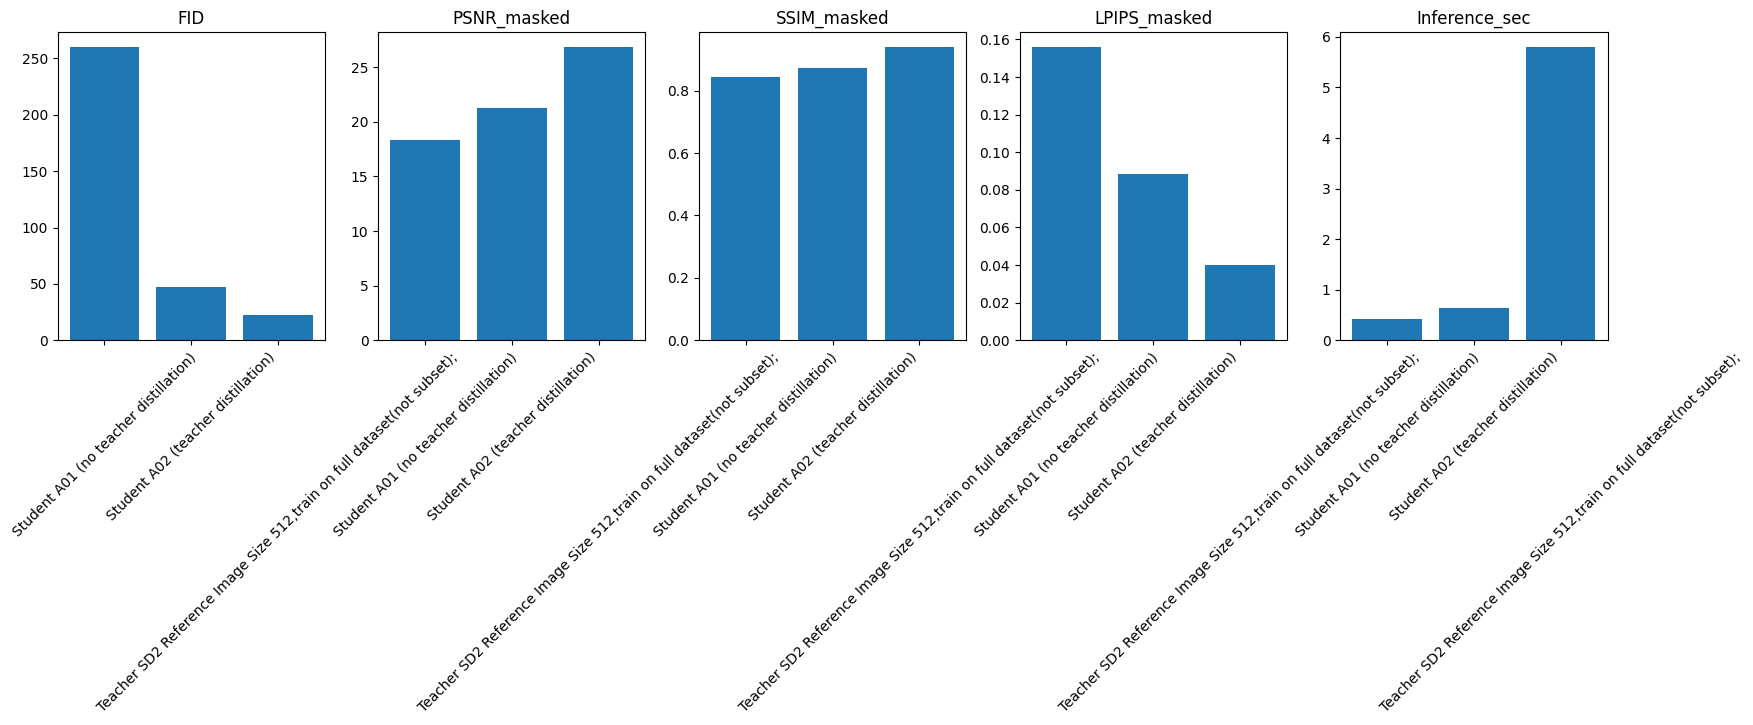

In [50]:
metrics_to_plot = ["FID", "PSNR_masked", "SSIM_masked", "LPIPS_masked", "Inference_sec"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 4))

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(comparison_df["Model"], comparison_df[metric])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [51]:
from pathlib import Path
import pandas as pd

# -------- Paths --------
image_root = Path(CFG["image_root"])

train_df = pd.read_csv(CFG["train_csv"])
val_df   = pd.read_csv(CFG["val_csv"])
test_df  = pd.read_csv(CFG["test_csv"])

# -------- Full dataset --------
all_images = [p for p in image_root.iterdir() if p.is_file()]
total_images = len(all_images)

# -------- Subset --------
subset_files = list(train_df["filename"]) + list(val_df["filename"]) + list(test_df["filename"])
subset_paths = [image_root / f for f in subset_files if (image_root / f).exists()]
subset_images = len(subset_paths)

# -------- Sizes --------
total_size_bytes = sum(p.stat().st_size for p in all_images)
subset_size_bytes = sum(p.stat().st_size for p in subset_paths)

total_size_gb = total_size_bytes / (1024**3)
subset_size_gb = subset_size_bytes / (1024**3)

# -------- Percentage --------
ratio_count = (subset_images / total_images) * 100
ratio_size = (subset_size_bytes / total_size_bytes) * 100

# -------- Print --------
print("\n===== DATASET SUMMARY =====\n")

print("Full Dataset:")
print(" Total images:", total_images)
print(" Total size  :", round(total_size_gb, 3), "GB")

print("\nSubset Used:")
print(" Train:", len(train_df))
print(" Val  :", len(val_df))
print(" Test :", len(test_df))
print(" Total subset images:", subset_images)
print(" Subset size:", round(subset_size_gb, 3), "GB")

print("\nUsage:")
print(" % of dataset used (count):", round(ratio_count, 2), "%")
print(" % of dataset used (size) :", round(ratio_size, 2), "%")

print("\n============================\n")


===== DATASET SUMMARY =====

Full Dataset:
 Total images: 202599
 Total size  : 1.313 GB

Subset Used:
 Train: 3000
 Val  : 500
 Test : 500
 Total subset images: 4000
 Subset size: 0.026 GB

Usage:
 % of dataset used (count): 1.97 %
 % of dataset used (size) : 1.97 %


